# Camera with Lab Server
This is an example of using the camera server to take data while also communicating with the lab server for exercising the shutter, filter wheels, and ammeter for running characterization scripts.

In [ ]:
# Camera Server

from pirtcam.client import CameraClient

# Connect to the camera server
cam = CameraClient("localhost", 5555)
cam.connect()

# Make sure the camera has all corrections turned off
cam.set_correction("GAIN", "OFF")
cam.set_correction("OFFSET", "OFF")   
cam.set_correction("SUB", "OFF")




Connected to camera server at localhost:5555


{'status': 'success', 'message': 'Substitution correction set to OFF'}

In [2]:
import numpy as np

# Make a list of exposure times
exptimes = np.array([0.1])



In [2]:
# Lab Hardware Control
import Pyro5.api as pyro

# Connect to the lab server
labserver = pyro.Proxy("PYRO:LabServer@localhost:50000")



In [4]:
# Observing Sequence
import json
import time

# Set the filter wheel to the desired position
labserver.select_bandpass(1050)      # 1250 nm in path
# Print out the current status of all connected wheels
for wheel in labserver.status()["online_wheels"]:
    print(f'wheel {wheel}: {json.dumps(labserver.wheel_status(wheel)["current_filter"], indent = 2)}')


# Close the shutter
print("Closing the shutter...")
labserver.shutter("close")
print(f'Shutter state: {labserver.status()["shutter"]["state"]}')

# Read the photodiode current
print("Reading the photodiode current...")
read_dark = labserver.read_multisample_current(10, dt=0.1, return_arr=True)
print(f"Mean photodiode current: {read_dark['mean']*1e9} nA")

# Take DARK sequence
header = {
    "OBSTYPE": "DARK",
    }
exptime = exptimes[0]
exptime = 10.0
n_exposures = 1
cam.set_exposure(exptime)

print(f"Taking DARK stack of {n_exposures} frames with exposure time {exptime} s")
cam.capture_frames(n_exposures, stack = True, headers = header, show_progress = True)

# Open the shutter
print("Opening the shutter...")
labserver.shutter("open")
print(f'Shutter state: {labserver.status()["shutter"]["state"]}')
time.sleep(30.0)  # Wait for the shutter to open and stabilize

# Reach the photodiode current
print("Reading the photodiode current...")
read_light = labserver.read_multisample_current(10, dt=0.1, return_arr=True)
print(f"Mean photodiode current: {read_light['mean']*1e9} nA")

# Take the LIGHT sequence
header = {
    "OBSTYPE": "LIGHT",
    }
print(f"Taking LIGHT stack of {n_exposures} frames with exposure time {exptime} s")
cam.capture_frames(n_exposures, stack = True, headers = header, show_progress = True)



# Profit.




wheel fw1: "FBH 1050-10"
wheel fw3: "EMPTY"
Closing the shutter...
Shutter state: closed
Reading the photodiode current...
Mean photodiode current: 6.9947482 nA
Taking DARK stack of 1 frames with exposure time 10.0 s
Capturing stack: 29.2s elapsed...
Stack capture in progress: 30.1s elapsed (~100% estimated)

Opening the shutter...
Shutter state: open
Reading the photodiode current...
Mean photodiode current: 7.594345799999999 nA
Taking LIGHT stack of 1 frames with exposure time 10.0 s
Capturing stack: 29.2s elapsed...
Stack capture in progress: 30.1s elapsed (~100% estimated)



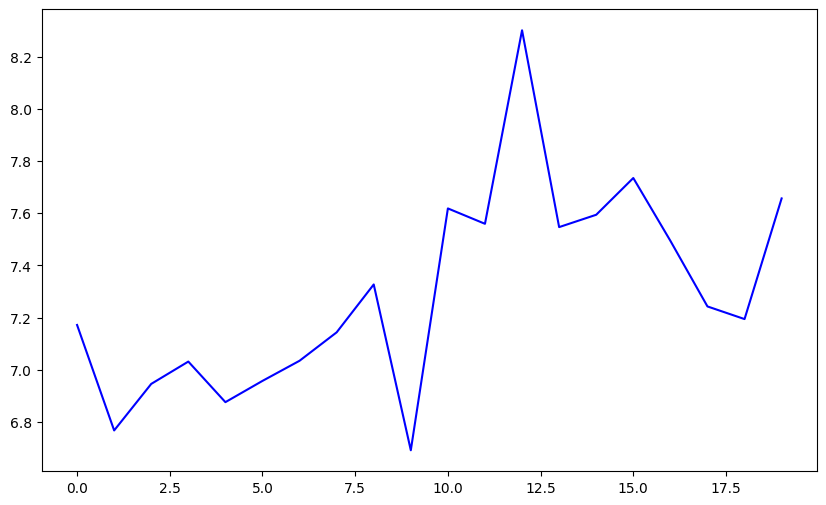

In [5]:
# Plot the photocurrent
import matplotlib.pyplot as plt

all_current = np.array(read_dark["samples"] + read_light["samples"])*1e9  # Convert to nA

plt.figure(figsize=(10, 6))
plt.plot(all_current, label="Dark Current", color='blue')

In [6]:
labserver.shutter("open")


In [ ]:
# DC Ramp
import json
ftype = "LIGHT" # frame type
selected_filter = 1150

obstype = ftype

if ftype == "DARK":
    labserver.shutter("close")
else:
    labserver.shutter("open")



print(json.dumps(header, indent=2))

# can i actually run a ramp??
import time

labserver.select_bandpass(1350)
exptimes = [1.0, 2., 5., 10.]    
exptimes = [0.001,
            0.002,
            0.003,
            0.004,
            0.005,
            0.006,
            0.007,
            0.008,
            0.009,
            0.01,
            0.02,
            0.03,
            0.04,
            0.05,
            0.06,
            0.07,
            0.08,
            0.09,
            0.1,
            0.25,
            0.5,
            0.075,
            0.5,
            0.75,
            1.0,
            2.0,
            3.0,
            4.0,
            5.0,
            6.0,
            7.0,
            8.0,
            9.0,
            10.0,
]



for exptime in exptimes:
    cam.set_exposure(exptime)
    time.sleep(30)
    cam.set_exposure(exptime)

    labserver.status()["shutter"]["state"]
    labserver.select_bandpass(selected_filter)      

    pd_read = labserver.read_multisample_current(60, dt=0.1, return_arr=True)

    target = "sphere" # or mirror, etc.

    header = {
        "OBSTYPE": ftype,
        "FRMETYP": ftype,
        "SHUTTER": labserver.status()["shutter"]["state"],
        "FILTER" : selected_filter,
        "PDCMEAN": pd_read["mean"],
        "PDCSTD": pd_read["std"],
        "PDCMED": pd_read["median"],
        "PDCNSAM": pd_read["n_samples"],
        "TARGET": target,
        }

    print(f"Taking frame with exposure time {exptime} s")
    # capture some dummy frames
    cam.capture_frames(25, stack = False, headers = header, show_progress = False)
    time.sleep(2.0)  # Wait for the camera to finish processing


{
  "OBSTYPE": "LIGHT",
  "FRMETYP": "LIGHT",
  "SHUTTER": "open",
  "FILTER": 1350,
  "PDCMEAN": 6.6160468999999995e-09,
  "PDCSTD": 3.5663841762055026e-10,
  "PDCMED": 6.696844e-09,
  "PDCNSAM": 10,
  "TARGET": "sphere"
}


In [ ]:
# Notes on exptimes

#approx_sat = 
# 1050: 10 s -> 4420 counts
# 1150: 10 s -> 14256 counts
#        5 s -> 11750 counts
#        2 s ->  6263 counts
#        1 s -> 4400 counts
# 1250:  1 s -> 3072 counts
#        5 s -> 4952 counts
#       10 s ->   counts
# 1350 : 5 s ->  3806 counts
#       : 10 s ->  6000 counts


SyntaxError: invalid syntax (3165506597.py, line 3)

In [15]:
# can i actually run a ramp??
import time

labserver.select_bandpass(1350)
exptimes = [1.0, 2., 5., 10.]    

for exptime in exptimes:
    cam.set_exposure(exptime)
    time.sleep(30)
    cam.set_exposure(exptime)
    time.sleep(30)
    print(f"Taking frame with exposure time {exptime} s")
    # capture some dummy frames
    cam.capture_frames(1, stack = False, headers = header, show_progress = False)
    time.sleep(2.0)  # Wait for the camera to finish processing

Taking frame with exposure time 1.0 s
Taking frame with exposure time 2.0 s
Taking frame with exposure time 5.0 s
Taking frame with exposure time 10.0 s
